In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#carregar dado
df = pd.DataFrame(pd.read_csv('dados_2025.csv'))
# Limpeza de dados 
#Arrumar valor de transação
df['valorTransacao'] = pd.to_numeric(df['valorTransacao']. 
                        str.replace('.', ''). #retira o . da casa de milhares
                        str.replace(',', '.'). #substitui , de centavos para .
                        str.replace('- ', '-') #substitui
)
df['dataTransacao'] = pd.to_datetime(df['dataTransacao']. 
                        str.replace('Sem informação', '01/01/2025'),
                        dayfirst=True
)
df = df[df['dataTransacao'].dt.year == 2025]
df = df.drop_duplicates()

In [ ]:
frac = df.groupby(['dataTransacao','portador.nome','estabelecimento.nome']).size().reset_index(name='contagem')
frac = frac.drop(1) #transações sigilosas (sem data, nome e etc)
df = df.merge(frac, on=['dataTransacao','portador.nome','estabelecimento.nome'], how='left')
df['flag_frac'] = df['contagem'] > 5

In [ ]:
# Flag IQR por órgão
def flag_iqr(group):
    Q1 = group['valorTransacao'].quantile(0.25)
    Q3 = group['valorTransacao'].quantile(0.75)
    IQR = Q3 - Q1
    group['flag_iqr'] = group['valorTransacao'] > Q3 + 1.5 * IQR
    return group

df = df.groupby("unidadeGestora.orgaoMaximo.nome", group_keys=False).apply(flag_iqr)


C:\Users\WinJoao\AppData\Local\Temp\ipykernel_2988\1365512786.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("unidadeGestora.orgaoMaximo.nome", group_keys=False).apply(flag_iqr)


In [22]:
df['score_suspeito'] = df['flag_iqr'].astype(int) + df['flag_frac'].astype(int)


In [ ]:
suspeitos = df[df['score_suspeito'] >= 2].sort_values('score_suspeito', ascending=False)
suspeitos.to_csv('suspeitos.csv')
print(suspeitos[['valorTransacao', 'dataTransacao', 'estabelecimento.nome',  'unidadeGestora.orgaoMaximo.nome']].head(10)) 

        valorTransacao dataTransacao               estabelecimento.nome  \
7156           1699.95    2025-06-17     R G S COMERCIO E SERVICOS LTDA   
71927        150423.02    2025-12-19                 MK CONSTRUCAO LTDA   
128042         3558.54    2025-03-21                     SEM INFORMACAO   
118375         2808.00    2025-11-27  ENCANTO DO VALE DESCARTAVEIS LTDA   
118373         2845.70    2025-11-27  ENCANTO DO VALE DESCARTAVEIS LTDA   
118371         2856.00    2025-11-27  ENCANTO DO VALE DESCARTAVEIS LTDA   
118369         2859.40    2025-11-27  ENCANTO DO VALE DESCARTAVEIS LTDA   
118367         2836.18    2025-11-27  ENCANTO DO VALE DESCARTAVEIS LTDA   
118365         1468.95    2025-11-27  ENCANTO DO VALE DESCARTAVEIS LTDA   
111633         2430.00    2025-03-27             JHONATAN DEMARCO ROCHA   

                   estabelecimento.tipo  \
7156    Entidades Empresariais Privadas   
71927   Entidades Empresariais Privadas   
128042                   Sem Informação   
11

In [24]:
def iqr_outliers(group):
    Q1 = group['valorTransacao'].quantile(0.25)
    Q3 = group['valorTransacao'].quantile(0.75)
    IQR = Q3 - Q1
    return group[group['valorTransacao'] > Q3 + 1.5 * IQR]

outliers_iqr = df.groupby("unidadeGestora.orgaoMaximo.nome", group_keys=False).apply(iqr_outliers)

C:\Users\WinJoao\AppData\Local\Temp\ipykernel_2988\12598450.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers_iqr = df.groupby("unidadeGestora.orgaoMaximo.nome", group_keys=False).apply(iqr_outliers)


In [25]:
print(outliers_iqr)

       Unnamed: 0.1  Unnamed: 0         id mesExtrato dataTransacao  \
9810          10368       10368  478827644    04/2025    2025-03-10   
9811          10369       10369  478827708    04/2025    2025-03-11   
10281         11077       11077  478852924    08/2025    2025-06-30   
11161         11957       11957  478881084    12/2025    2025-11-19   
11319         12115       12115  478886140    01/2026    2025-12-19   
...             ...         ...        ...        ...           ...   
70867         76589       76589  495332870    10/2025    2025-09-03   
71265         76987       76987  495358342    12/2025    2025-11-25   
71267         76989       76989  495358470    12/2025    2025-11-24   
71855         77577       77577  495396102    01/2026    2025-12-12   
71856         77578       77578  495396166    01/2026    2025-12-22   

       valorTransacao  tipoCartao.id  tipoCartao.codigo  \
9810          1510.00              1                  1   
9811          1510.00        

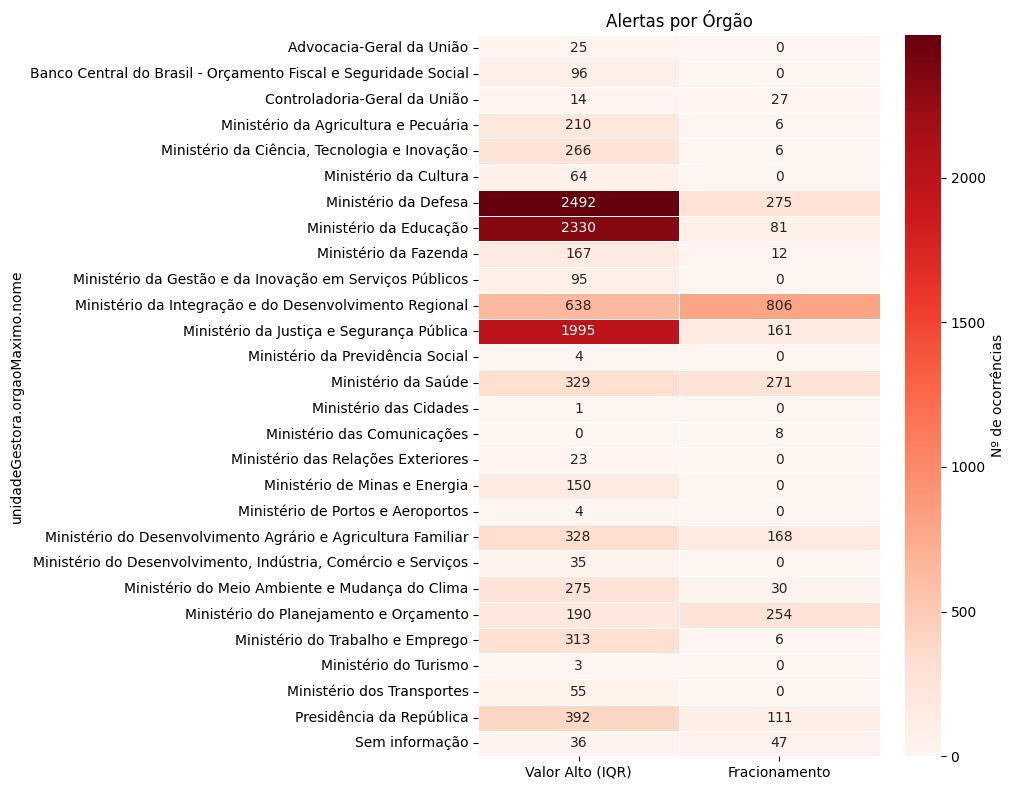

In [31]:
flag_cols = ['flag_iqr',  'flag_frac']
heat_flags = df.groupby('unidadeGestora.orgaoMaximo.nome')[flag_cols].sum()
heat_flags.columns = ['Valor Alto (IQR)', 'Fracionamento']
heat_flags = heat_flags[heat_flags.sum(axis=1) > 0]  # ignora sem alertas

plt.figure(figsize=(10, 8))
sns.heatmap(heat_flags, annot=True, fmt='.0f', cmap='Reds',
            linewidths=0.4, cbar_kws={'label': 'Nº de ocorrências'})
plt.title('Alertas por Órgão')
plt.savefig('assets/Alertas_orgao.png')
plt.tight_layout()
plt.show()